In [ ]:
#Setup và Import thư viện
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Chuẩn bị dữ liệu (Data Pipeline)
# Normalize dữ liệu về khoảng [-1, 1] theo chuẩn Stanford CS231n
transform = transforms.Compose([ #khởi động dây chuyền xử lí ảnh
    transforms.ToTensor(), # Chuyển ảnh sang định dạng Tensor(ma trận số)
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) #Chuẩn hóa
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
#Lấy dữ liệu
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
# Chia nhỏ dữ liệu thành các nhóm 32 ảnh để không bị tràn RAM

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)


classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print("Đã tải xong dữ liệu")

100%|██████████| 170M/170M [00:06<00:00, 28.2MB/s]


Đã tải xong dữ liệu


In [ ]:
## 3. Neural Network Architecture (Xây dựng mạng nơ-ron)

class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()

        # Bước 1: Flatten - Duỗi phẳng ảnh 3D thành vector 1D
        # Ảnh CIFAR-10: 32x32x3 => 3072 số.
        self.flatten = nn.Flatten()

        # Bước 2: Định nghĩa các lớp nơ-ron (Layers) theo mô hình tuần tự
        self.layers = nn.Sequential(
            # Lớp ẩn 1: Nhận 3072 đầu vào, học ra 512 đặc trưng
            nn.Linear(3072, 512),
            nn.ReLU(), # Hàm kích hoạt phi tuyến (quả bóng vàng trong hình MIT)

            # Lớp ẩn 2: Từ 512 đặc trưng học tiếp xuống 256 đặc trưng
            nn.Linear(512, 256),
            nn.ReLU(),

            # Lớp đầu ra (Output): Phải là 10 vì có 10 lớp đối tượng (classes)
            nn.Linear(256, 10)
        )

    def forward(self, x):
        # Dữ liệu đi vào (Input) -> Duỗi phẳng -> Đi qua các lớp -> Kết quả (Logits)
        x = self.flatten(x)
        logits = self.layers(x)
        return logits

# Khởi tạo mô hình và đưa vào GPU (nếu có) để tính toán nhanh hơn
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SimpleMLP().to(device)

print(f"Mô hình đã được khởi tạo trên: {device}")
print(model)

Mô hình đã được khởi tạo trên: cuda
SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): Sequential(
    (0): Linear(in_features=3072, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [ ]:
## 4. Loss Function & Optimizer (Hàm mất mát và Bộ tối ưu)
criterion = nn.CrossEntropyLoss() # Vị trọng tài tính sai số (Error)
optimizer = optim.Adam(model.parameters(), lr=0.001) # Người thợ vặn nút (Trọng số)

## 5. Training Loop (Vòng lặp huấn luyện)
epochs = 5 # Cho máy học đi học lại 5 lần toàn bộ 50,000 ảnh
train_losses = []

print("Bắt đầu quá trình huấn luyện")

for epoch in range(epochs):
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # Lấy dữ liệu (ảnh và nhãn) đưa vào device (CPU hoặc GPU)
        inputs, labels = data[0].to(device), data[1].to(device)

        # 1. Xóa gradient cũ (Reset bộ nhớ sửa sai)
        optimizer.zero_grad()

        # 2. Forward pass: Máy đưa ra dự đoán
        outputs = model(inputs)

        # 3. Tính toán Error: Xem dự đoán sai bao nhiêu so với nhãn thật
        loss = criterion(outputs, labels)

        # 4. Backward pass: Lan truyền ngược để tìm lỗi (Tấm hình MIT bạn gửi)
        loss.backward()

        # 5. Optimize: Cập nhật trọng số để lần sau đoán đúng hơn
        optimizer.step()

        running_loss += loss.item()

    # Tính loss trung bình của mỗi Epoch để vẽ biểu đồ
    avg_loss = running_loss / len(trainloader)
    train_losses.append(avg_loss)
    print(f"Lần học (Epoch) {epoch+1}/{epochs} - Sai số (Loss): {avg_loss:.4f}")

print("--- Huấn luyện xong! ---")

Bắt đầu quá trình huấn luyện
Lần học (Epoch) 1/5 - Sai số (Loss): 1.6589
Lần học (Epoch) 2/5 - Sai số (Loss): 1.4598
Lần học (Epoch) 3/5 - Sai số (Loss): 1.3552
Lần học (Epoch) 4/5 - Sai số (Loss): 1.2711
Lần học (Epoch) 5/5 - Sai số (Loss): 1.1980
--- Huấn luyện xong! ---


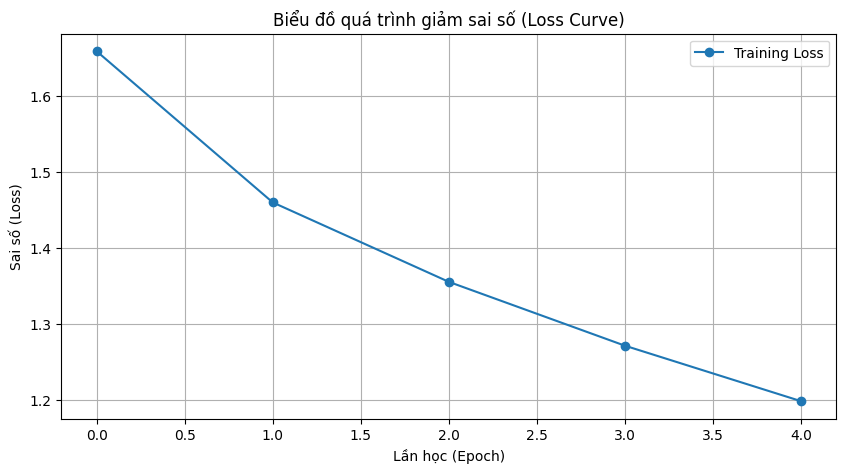

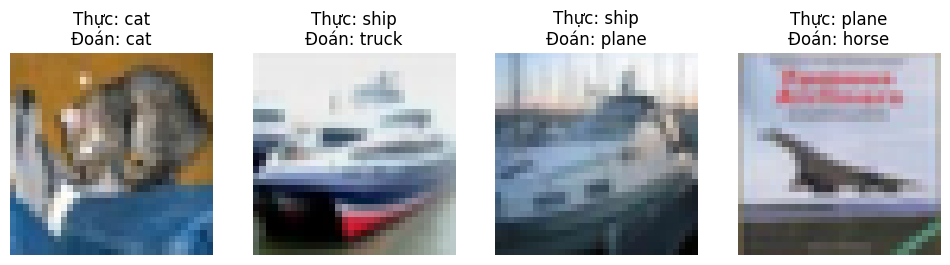

In [ ]:
## 6. Evaluation & Visualization (Đánh giá và Trực quan hóa)

# 1. Vẽ biểu đồ quá trình học tập
plt.figure(figsize=(10, 5))
plt.plot(train_losses, marker='o', label='Training Loss')
plt.title('Biểu đồ quá trình giảm sai số (Loss Curve)')
plt.xlabel('Lần học (Epoch)')
plt.ylabel('Sai số (Loss)')
plt.legend()
plt.grid(True)
plt.show()

# 2. Dự đoán thử trên một vài tấm ảnh thực tế
dataiter = iter(testloader)
images, labels = next(dataiter)

# Cho máy dự đoán
outputs = model(images.to(device))
_, predicted = torch.max(outputs, 1)

# Hiển thị 4 tấm ảnh đầu tiên và kết quả máy đoán
plt.figure(figsize=(12, 4))
for i in range(4):
    plt.subplot(1, 4, i+1)
    # Convert tensor về dạng ảnh để hiển thị (xong chuẩn hóa ngược)
    img = images[i] / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(f"Thực: {classes[labels[i]]}\nĐoán: {classes[predicted[i]]}")
    plt.axis('off')
plt.show()